# FFT Attack Study and Rotation Synchronization for Watermarking

This notebook builds reproducible tests in `LSB/tests` using images from `LSB/img`.

Goals:
- Apply spatial-domain attacks: rotation, blur, JPEG compression.
- Visualize spatial images and their FFT-domain signatures.
- Estimate rotation with FFT log-polar + phase correlation.
- Compare watermark decoding before vs after FFT-based rotation synchronization.

## 1) Set Up Notebook Paths, Imports, and Reproducibility

This section:
- Resolves project paths with `pathlib`.
- Imports `numpy`, `cv2`, `matplotlib`, `pandas`, and `WatermarkModel`.
- Sets random seeds for repeatable experiments.
- Creates output folders for attacked images, figures, and summary tables.

In [1]:
from pathlib import Path
import sys
import math
from typing import Dict, List, Tuple

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

np.random.seed(7)
cv2.setRNGSeed(7)

plt.rcParams.update({
    "figure.dpi": 110,
    "figure.figsize": (8, 5),
    "image.cmap": "gray",
})


def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "LSB" / "model.py").exists():
            return candidate
    raise FileNotFoundError("Could not locate project root containing LSB/model.py")


PROJECT_ROOT = find_project_root(Path.cwd())
LSB_DIR = PROJECT_ROOT / "LSB"
IMG_DIR = LSB_DIR / "img"
TESTS_DIR = LSB_DIR / "tests"
OUT_DIR = TESTS_DIR / "fft_rotation_sync_outputs"

for sub in ["attacks", "figures", "tables"]:
    (OUT_DIR / sub).mkdir(parents=True, exist_ok=True)

if str(LSB_DIR) not in sys.path:
    sys.path.insert(0, str(LSB_DIR))

from model import WatermarkModel

print(f"PROJECT_ROOT: {PROJECT_ROOT}")
print(f"IMG_DIR:      {IMG_DIR}")
print(f"OUT_DIR:      {OUT_DIR}")

PROJECT_ROOT: c:\Users\Sinbad\Documents\GitHub\multimedia_security_and_privacy
IMG_DIR:      c:\Users\Sinbad\Documents\GitHub\multimedia_security_and_privacy\LSB\img
OUT_DIR:      c:\Users\Sinbad\Documents\GitHub\multimedia_security_and_privacy\LSB\tests\fft_rotation_sync_outputs


## 2) Load Images from `LSB/img` and Build a Test Batch

We enumerate supported image files, load them with OpenCV, and store:
- Original BGR image.
- Grayscale image for FFT and watermark tests.
- Basic metadata (shape, dtype, path).

,name,shape,dtype,path
0,airplane.bmp,512x512,uint8,c:\Users\Sinbad\Documents\GitHub\multimedia_se...
1,baboon.bmp,480x500,uint8,c:\Users\Sinbad\Documents\GitHub\multimedia_se...
2,cameraman.png,256x256,uint8,c:\Users\Sinbad\Documents\GitHub\multimedia_se...
3,man.bmp,1024x1024,uint8,c:\Users\Sinbad\Documents\GitHub\multimedia_se...
4,tangled_small.jpg,512x634,uint8,c:\Users\Sinbad\Documents\GitHub\multimedia_se...


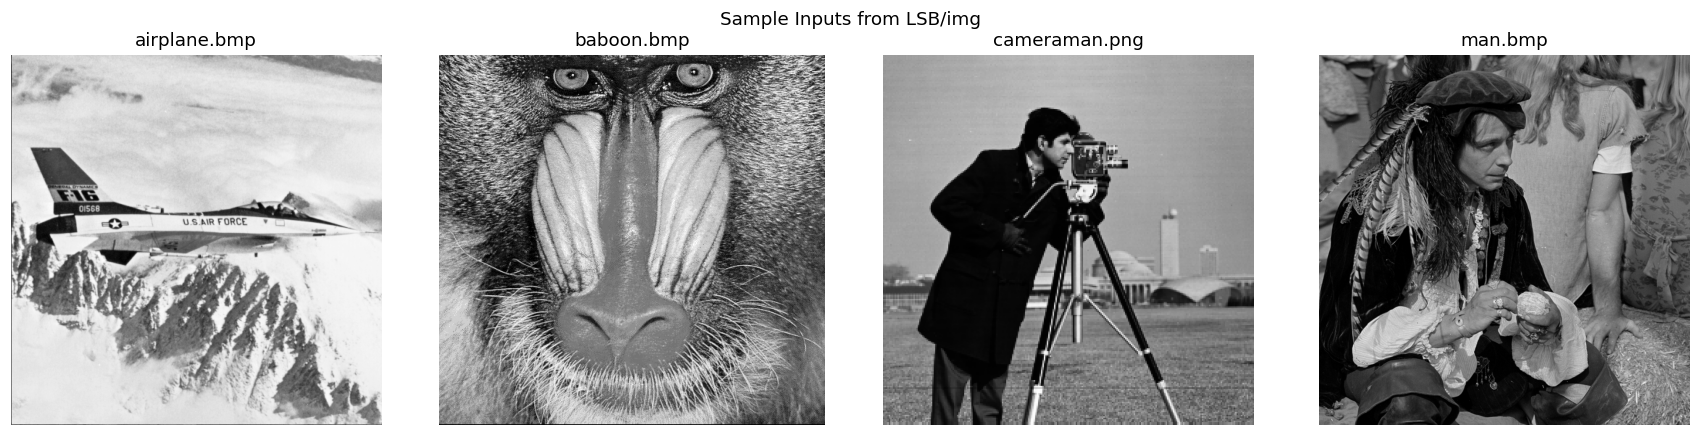

In [2]:
SUPPORTED_EXT = {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff"}

image_records: List[Dict[str, object]] = []
for path in sorted(IMG_DIR.iterdir()):
    if path.is_dir() or path.suffix.lower() not in SUPPORTED_EXT:
        continue

    bgr = cv2.imread(str(path), cv2.IMREAD_COLOR)
    if bgr is None:
        print(f"[WARN] Could not read image: {path}")
        continue

    gray = cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY)
    image_records.append(
        {
            "name": path.name,
            "stem": path.stem,
            "path": path,
            "bgr": bgr,
            "gray": gray,
            "height": gray.shape[0],
            "width": gray.shape[1],
            "dtype": str(gray.dtype),
        }
    )

if not image_records:
    raise RuntimeError(f"No supported images found in {IMG_DIR}")

images_df = pd.DataFrame(
    [
        {
            "name": r["name"],
            "shape": f"{r['height']}x{r['width']}",
            "dtype": r["dtype"],
            "path": str(r["path"]),
        }
        for r in image_records
    ]
)

display(images_df)

n_show = min(4, len(image_records))
fig, axes = plt.subplots(1, n_show, figsize=(4 * n_show, 4))
if n_show == 1:
    axes = [axes]

for ax, rec in zip(axes, image_records[:n_show]):
    ax.imshow(rec["gray"], cmap="gray")
    ax.set_title(str(rec["name"]))
    ax.axis("off")

plt.suptitle("Sample Inputs from LSB/img")
plt.tight_layout()
plt.show()

## 3) Implement Spatial-Domain Attacks (Rotation, Blur, JPEG Compression)

Reusable attack functions are defined here. They preserve `uint8` shape/type where practical and include explicit conversions.

In [3]:
def to_gray_u8(image: np.ndarray) -> np.ndarray:
    if image.ndim == 2:
        out = image
    elif image.ndim == 3:
        out = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    else:
        raise ValueError(f"Unsupported image shape: {image.shape}")

    if out.dtype != np.uint8:
        out = np.clip(out, 0, 255).astype(np.uint8)
    return out


def rotate_image(
    image: np.ndarray,
    angle_deg: float,
    interpolation: int = cv2.INTER_CUBIC,
    border: int = cv2.BORDER_REFLECT101,
) -> np.ndarray:
    h, w = image.shape[:2]
    center = (w / 2.0, h / 2.0)
    M = cv2.getRotationMatrix2D(center, angle_deg, 1.0)
    rotated = cv2.warpAffine(
        image,
        M,
        (w, h),
        flags=interpolation,
        borderMode=border,
    )
    return rotated


def blur_image(image: np.ndarray, kernel_size: int = 5, sigma: float = 1.2) -> np.ndarray:
    k = int(kernel_size)
    if k <= 1:
        return image.copy()
    if k % 2 == 0:
        k += 1
    return cv2.GaussianBlur(
        image,
        (k, k),
        sigmaX=float(sigma),
        sigmaY=float(sigma),
        borderType=cv2.BORDER_REFLECT101,
    )


def jpeg_compress(image: np.ndarray, quality: int = 90) -> np.ndarray:
    q = int(np.clip(quality, 1, 100))
    params = [int(cv2.IMWRITE_JPEG_QUALITY), q]
    ok, enc = cv2.imencode(".jpg", image, params)
    if not ok:
        raise RuntimeError("JPEG encode failed")
    dec = cv2.imdecode(enc, cv2.IMREAD_UNCHANGED)
    if dec is None:
        raise RuntimeError("JPEG decode failed")
    return dec


def apply_attack_pipeline(
    image: np.ndarray,
    angle_deg: float = 0.0,
    blur_kernel: int = 1,
    blur_sigma: float = 0.0,
    jpeg_quality: int = 100,
) -> np.ndarray:
    out = image.copy()
    if abs(float(angle_deg)) > 1e-9:
        out = rotate_image(out, float(angle_deg))
    if int(blur_kernel) > 1:
        out = blur_image(out, int(blur_kernel), float(blur_sigma))
    if int(jpeg_quality) < 100:
        out = jpeg_compress(out, int(jpeg_quality))

    if out.dtype != np.uint8:
        out = np.clip(out, 0, 255).astype(np.uint8)
    return out


def center_crop(image: np.ndarray, frac: float = 0.8) -> np.ndarray:
    frac = float(np.clip(frac, 0.1, 1.0))
    h, w = image.shape[:2]
    ch, cw = int(round(h * frac)), int(round(w * frac))
    y0 = (h - ch) // 2
    x0 = (w - cw) // 2
    return image[y0:y0 + ch, x0:x0 + cw]

## 4) Generate an Attack Matrix and Persist Outputs in `LSB/tests`

We create a grid of attack parameters and save every attacked output image in:

`LSB/tests/fft_rotation_sync_outputs/attacks`

A metadata table is stored as CSV for reproducible downstream analysis.

In [4]:
angles = [0, -30, -15, 15, 30]
blur_params = [(1, 0.0), (3, 0.8), (7, 1.6)]
jpeg_qualities = [100, 90, 70, 40]

attack_rows: List[Dict[str, object]] = []
for rec in image_records:
    stem = str(rec["stem"])
    src = np.asarray(rec["gray"], dtype=np.uint8)

    out_subdir = OUT_DIR / "attacks" / stem
    out_subdir.mkdir(parents=True, exist_ok=True)

    for angle in angles:
        for blur_k, blur_sigma in blur_params:
            for jpeg_q in jpeg_qualities:
                attacked = apply_attack_pipeline(
                    src,
                    angle_deg=float(angle),
                    blur_kernel=int(blur_k),
                    blur_sigma=float(blur_sigma),
                    jpeg_quality=int(jpeg_q),
                )

                attack_id = (
                    f"{stem}_a{int(angle):+03d}_k{int(blur_k)}"
                    f"_s{blur_sigma:.1f}_q{int(jpeg_q)}"
                )
                out_path = out_subdir / f"{attack_id}.png"
                cv2.imwrite(str(out_path), attacked)

                attack_rows.append(
                    {
                        "image_name": rec["name"],
                        "image_stem": stem,
                        "attack_id": attack_id,
                        "angle_deg": float(angle),
                        "blur_kernel": int(blur_k),
                        "blur_sigma": float(blur_sigma),
                        "jpeg_quality": int(jpeg_q),
                        "output_path": str(out_path),
                    }
                )

attack_df = pd.DataFrame(attack_rows)
attack_csv_path = OUT_DIR / "tables" / "attack_matrix.csv"
attack_df.to_csv(attack_csv_path, index=False)

print(f"Generated attacked samples: {len(attack_df)}")
print(f"Saved metadata CSV: {attack_csv_path}")
display(attack_df.head(12))

Generated attacked samples: 300
Saved metadata CSV: c:\Users\Sinbad\Documents\GitHub\multimedia_security_and_privacy\LSB\tests\fft_rotation_sync_outputs\tables\attack_matrix.csv


,image_name,image_stem,attack_id,angle_deg,blur_kernel,blur_sigma,jpeg_quality,output_path
0,airplane.bmp,airplane,airplane_a+00_k1_s0.0_q100,0.0,1,0.0,100,c:\Users\Sinbad\Documents\GitHub\multimedia_se...
1,airplane.bmp,airplane,airplane_a+00_k1_s0.0_q90,0.0,1,0.0,90,c:\Users\Sinbad\Documents\GitHub\multimedia_se...
2,airplane.bmp,airplane,airplane_a+00_k1_s0.0_q70,0.0,1,0.0,70,c:\Users\Sinbad\Documents\GitHub\multimedia_se...
3,airplane.bmp,airplane,airplane_a+00_k1_s0.0_q40,0.0,1,0.0,40,c:\Users\Sinbad\Documents\GitHub\multimedia_se...
4,airplane.bmp,airplane,airplane_a+00_k3_s0.8_q100,0.0,3,0.8,100,c:\Users\Sinbad\Documents\GitHub\multimedia_se...
5,airplane.bmp,airplane,airplane_a+00_k3_s0.8_q90,0.0,3,0.8,90,c:\Users\Sinbad\Documents\GitHub\multimedia_se...
6,airplane.bmp,airplane,airplane_a+00_k3_s0.8_q70,0.0,3,0.8,70,c:\Users\Sinbad\Documents\GitHub\multimedia_se...
7,airplane.bmp,airplane,airplane_a+00_k3_s0.8_q40,0.0,3,0.8,40,c:\Users\Sinbad\Documents\GitHub\multimedia_se...
8,airplane.bmp,airplane,airplane_a+00_k7_s1.6_q100,0.0,7,1.6,100,c:\Users\Sinbad\Documents\GitHub\multimedia_se...
9,airplane.bmp,airplane,airplane_a+00_k7_s1.6_q90,0.0,7,1.6,90,c:\Users\Sinbad\Documents\GitHub\multimedia_se...


## 5) Compute and Visualize 2D FFT (Shifted Spectrum + Log Magnitude)

Given grayscale image $I(x,y)$, we compute:

$$
F(u,v) = \mathcal{F}\{I(x,y)\}, \quad
F_s(u,v) = \mathrm{fftshift}(F), \quad
M(u,v) = \log(1 + |F_s(u,v)|)
$$

We also return phase maps and normalized display versions.

In [5]:
def fft2_spectrum(image: np.ndarray) -> Dict[str, np.ndarray]:
    gray = to_gray_u8(image).astype(np.float32)
    fft = np.fft.fft2(gray)
    fft_shift = np.fft.fftshift(fft)

    magnitude = np.abs(fft_shift)
    log_mag = np.log1p(magnitude)
    phase = np.angle(fft_shift)

    log_mag_norm = cv2.normalize(log_mag, None, 0.0, 1.0, cv2.NORM_MINMAX)
    phase_norm = (phase + np.pi) / (2.0 * np.pi)

    return {
        "gray": gray,
        "fft": fft,
        "fft_shift": fft_shift,
        "magnitude": magnitude,
        "log_mag": log_mag,
        "log_mag_norm": log_mag_norm.astype(np.float32),
        "phase": phase,
        "phase_norm": phase_norm.astype(np.float32),
    }


def radial_profile(map2d: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    arr = np.asarray(map2d, dtype=np.float64)
    h, w = arr.shape
    cy, cx = (h - 1) / 2.0, (w - 1) / 2.0

    yy, xx = np.indices((h, w), dtype=np.float64)
    rr = np.sqrt((yy - cy) ** 2 + (xx - cx) ** 2).astype(np.int32)

    sums = np.bincount(rr.ravel(), weights=arr.ravel())
    counts = np.bincount(rr.ravel())
    profile = sums / np.maximum(counts, 1)

    return np.arange(profile.shape[0]), profile


print("FFT helper functions ready.")

FFT helper functions ready.


## 6) Compare Spatial Images vs Fourier Signatures Across Attacks

For one reference image, we visualize:
- Spatial image
- FFT log magnitude
- Spatial absolute difference vs clean reference
- FFT-log absolute difference vs clean reference

We also compare radial profiles to show blur/compression attenuation trends.

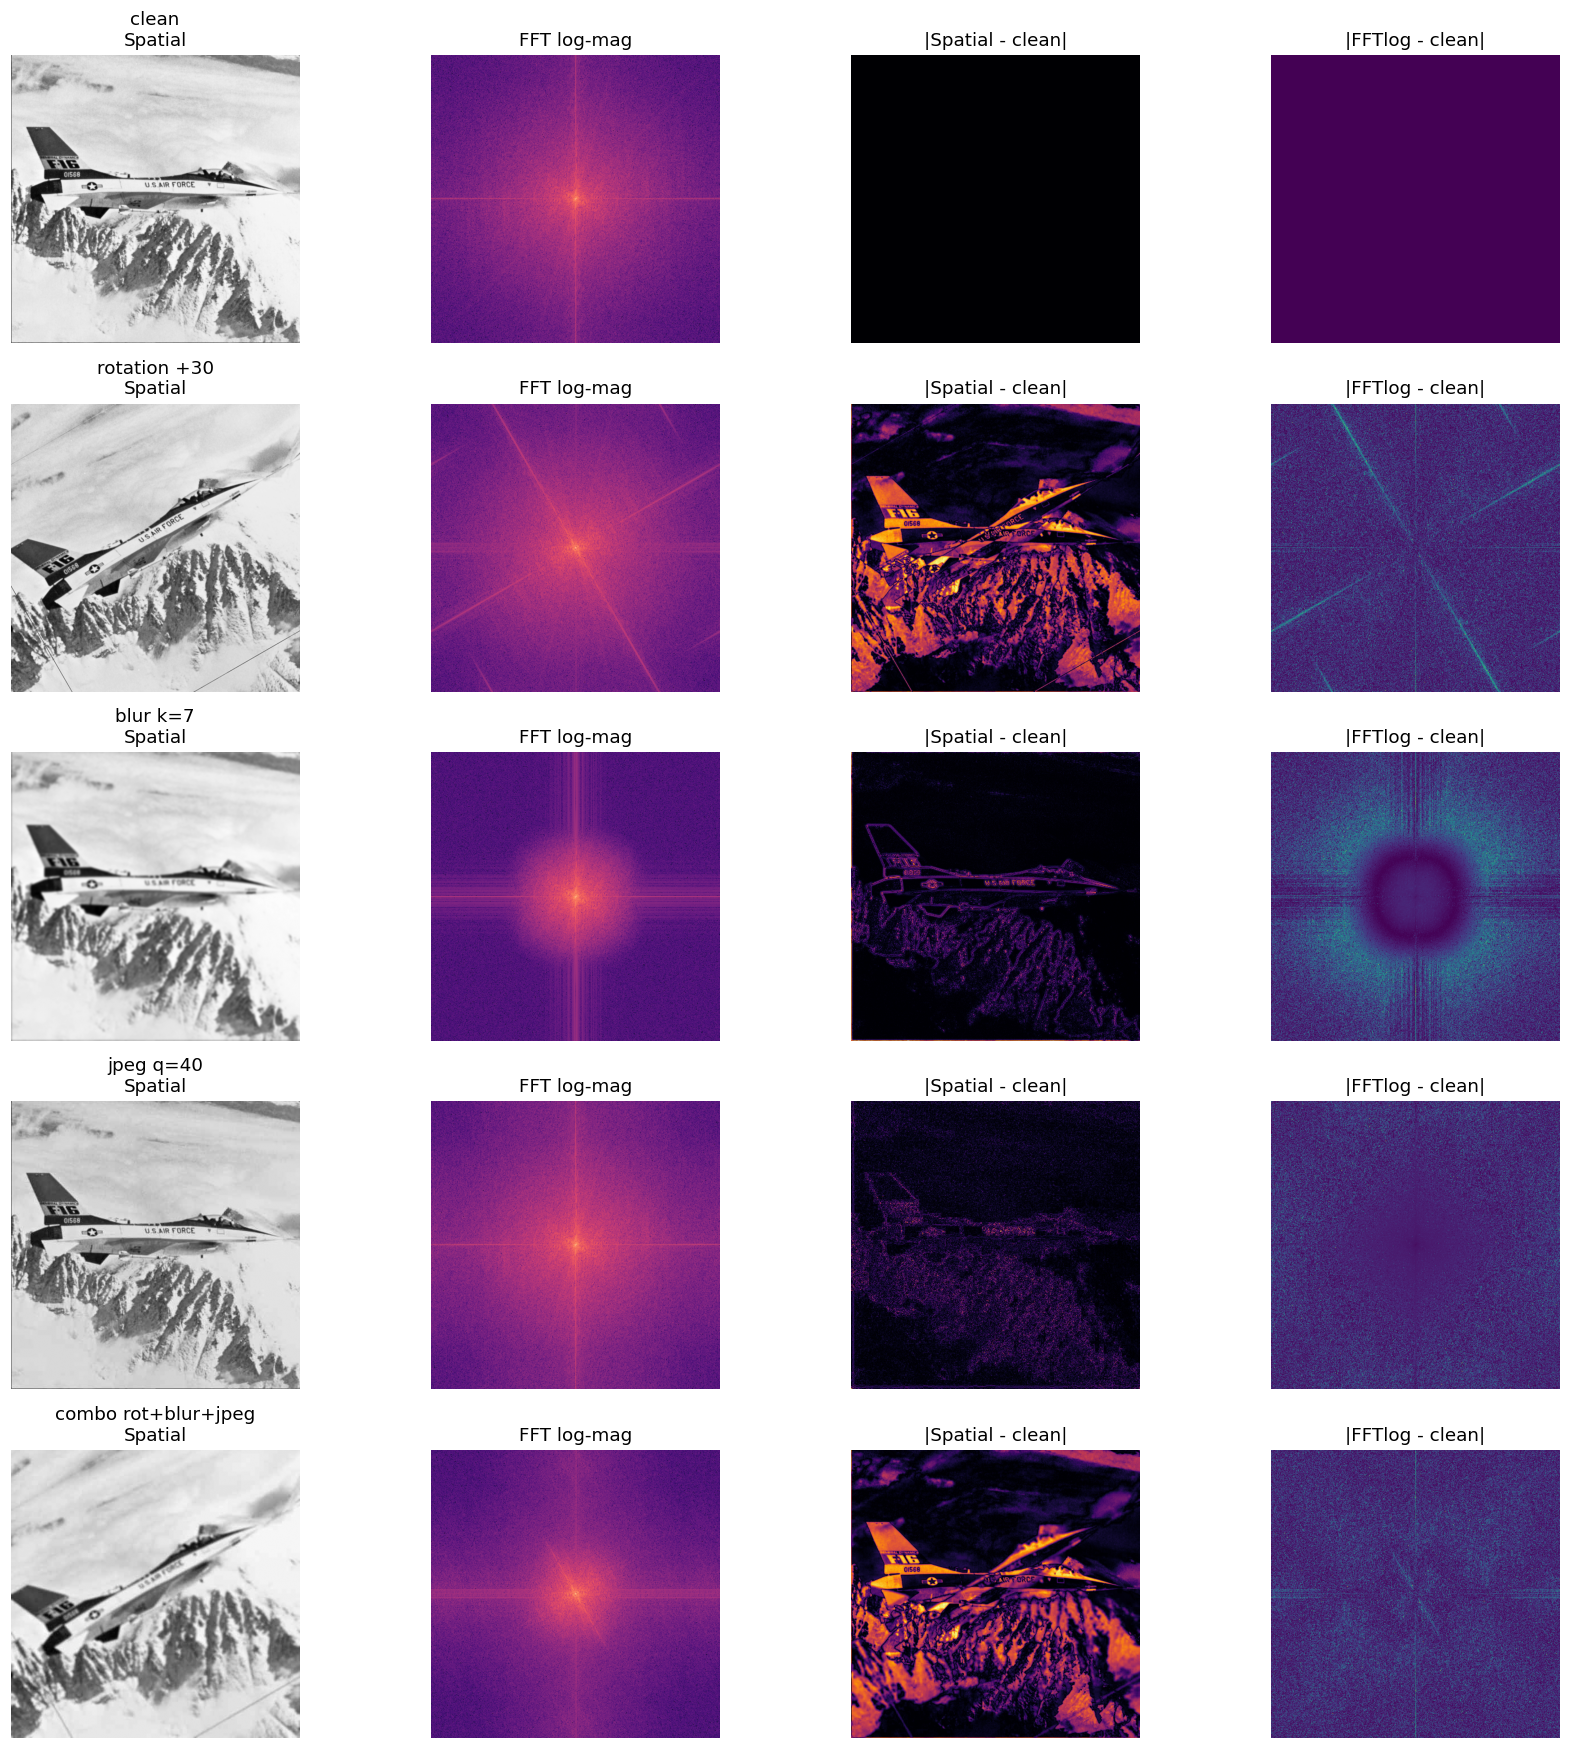

Saved figure: c:\Users\Sinbad\Documents\GitHub\multimedia_security_and_privacy\LSB\tests\fft_rotation_sync_outputs\figures\spatial_vs_fft_examples.png


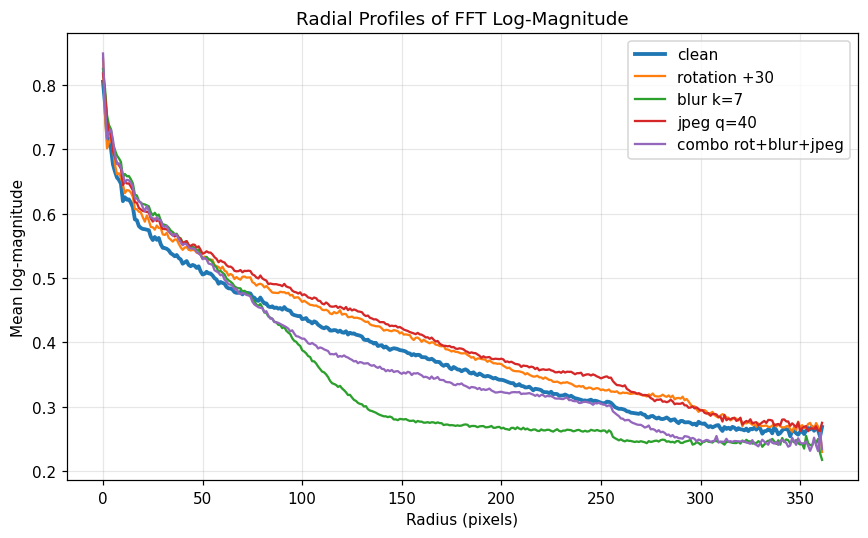

Saved figure: c:\Users\Sinbad\Documents\GitHub\multimedia_security_and_privacy\LSB\tests\fft_rotation_sync_outputs\figures\fft_radial_profiles.png


In [6]:
ref_image_name = str(image_records[0]["name"])
ref_stem = str(image_records[0]["stem"])
ref_clean = np.asarray(image_records[0]["gray"], dtype=np.uint8)

selection_specs = [
    (0, 1, 0.0, 100, "clean"),
    (30, 1, 0.0, 100, "rotation +30"),
    (0, 7, 1.6, 100, "blur k=7"),
    (0, 1, 0.0, 40, "jpeg q=40"),
    (30, 7, 1.6, 40, "combo rot+blur+jpeg"),
]

selected_rows = []
for angle, blur_k, blur_sigma, jpeg_q, tag in selection_specs:
    mask = (
        (attack_df["image_stem"] == ref_stem)
        & (attack_df["angle_deg"] == float(angle))
        & (attack_df["blur_kernel"] == int(blur_k))
        & (attack_df["blur_sigma"] == float(blur_sigma))
        & (attack_df["jpeg_quality"] == int(jpeg_q))
    )
    if not mask.any():
        print(f"[WARN] Missing case: {tag}")
        continue
    row = attack_df[mask].iloc[0].to_dict()
    row["tag"] = tag
    selected_rows.append(row)

if not selected_rows:
    raise RuntimeError("No selected attack rows found for visualization")

ref_fft = fft2_spectrum(ref_clean)

n = len(selected_rows)
fig, axes = plt.subplots(n, 4, figsize=(16, 3.2 * n))
if n == 1:
    axes = np.array([axes])

for i, row in enumerate(selected_rows):
    attacked = cv2.imread(str(row["output_path"]), cv2.IMREAD_GRAYSCALE)
    if attacked is None:
        raise RuntimeError(f"Could not read attacked image: {row['output_path']}")

    spec = fft2_spectrum(attacked)

    spatial_diff = cv2.absdiff(attacked, ref_clean)
    spectrum_diff = np.abs(spec["log_mag_norm"] - ref_fft["log_mag_norm"])

    axes[i, 0].imshow(attacked, cmap="gray")
    axes[i, 0].set_title(f"{row['tag']}\nSpatial")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(spec["log_mag_norm"], cmap="magma")
    axes[i, 1].set_title("FFT log-mag")
    axes[i, 1].axis("off")

    axes[i, 2].imshow(spatial_diff, cmap="inferno")
    axes[i, 2].set_title("|Spatial - clean|")
    axes[i, 2].axis("off")

    axes[i, 3].imshow(spectrum_diff, cmap="viridis")
    axes[i, 3].set_title("|FFTlog - clean|")
    axes[i, 3].axis("off")

plt.tight_layout()
fig_path = OUT_DIR / "figures" / "spatial_vs_fft_examples.png"
plt.savefig(fig_path, bbox_inches="tight")
plt.show()
print(f"Saved figure: {fig_path}")

plt.figure(figsize=(8, 5))
r_ref, p_ref = radial_profile(ref_fft["log_mag_norm"])
plt.plot(r_ref, p_ref, linewidth=2.5, label="clean")

for row in selected_rows[1:]:
    attacked = cv2.imread(str(row["output_path"]), cv2.IMREAD_GRAYSCALE)
    spec = fft2_spectrum(attacked)
    r, p = radial_profile(spec["log_mag_norm"])
    m = min(len(r_ref), len(r))
    plt.plot(r[:m], p[:m], label=str(row["tag"]))

plt.title("Radial Profiles of FFT Log-Magnitude")
plt.xlabel("Radius (pixels)")
plt.ylabel("Mean log-magnitude")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
radial_fig_path = OUT_DIR / "figures" / "fft_radial_profiles.png"
plt.savefig(radial_fig_path, bbox_inches="tight")
plt.show()
print(f"Saved figure: {radial_fig_path}")

## 7) Run Rotation Sweep and Track FFT-Domain Changes

We sweep angles from $-45^\circ$ to $45^\circ$ and track a simple spectrum-orientation descriptor derived from FFT log-magnitude second-order moments.

This descriptor is not a full estimator, but it helps visualize how spectrum structure responds to spatial rotation.

,true_angle_deg,spectrum_orientation_deg,orientation_wrapped_deg
0,-45.0,20.488155,20.488155
1,-40.0,31.621773,31.621773
2,-35.0,18.519227,18.519227
3,-30.0,5.049110,5.049110
4,-25.0,1.507974,1.507974
5,-20.0,-1.416581,-1.416581
6,-15.0,-7.538726,-7.538726
7,-10.0,-24.190322,-24.190322
8,-5.0,-26.260790,-26.260790
9,0.0,-37.100701,-37.100701


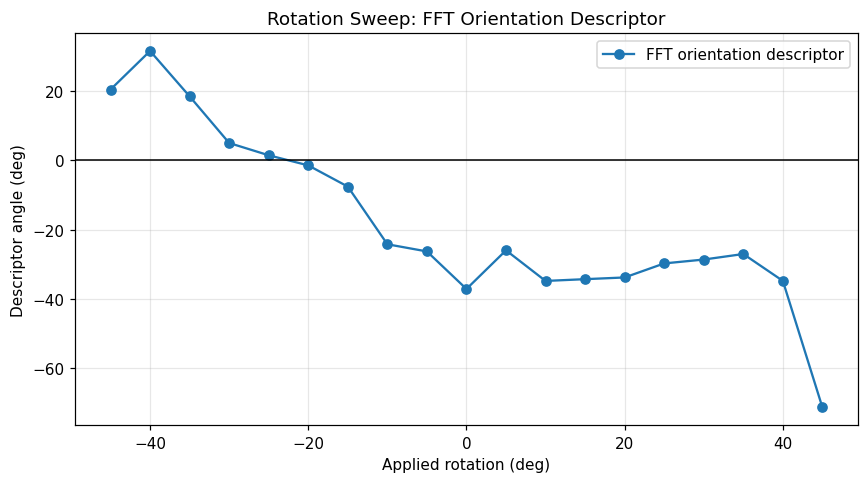

Saved figure: c:\Users\Sinbad\Documents\GitHub\multimedia_security_and_privacy\LSB\tests\fft_rotation_sync_outputs\figures\rotation_sweep_fft_descriptor.png


In [7]:
def wrap_angle_deg(angle: float) -> float:
    return ((float(angle) + 180.0) % 360.0) - 180.0


def spectrum_orientation_deg(log_mag_norm: np.ndarray) -> float:
    arr = np.asarray(log_mag_norm, dtype=np.float64)
    h, w = arr.shape
    cy, cx = (h - 1) / 2.0, (w - 1) / 2.0

    yy, xx = np.indices(arr.shape, dtype=np.float64)
    x = xx - cx
    y = yy - cy

    r2 = x * x + y * y
    r_min = (min(h, w) * 0.04) ** 2
    weights = arr.copy()
    weights[r2 < r_min] = 0.0

    s = weights.sum()
    if s <= 1e-12:
        return 0.0

    mx = (weights * x).sum() / s
    my = (weights * y).sum() / s
    x0 = x - mx
    y0 = y - my

    cov_xx = (weights * x0 * x0).sum() / s
    cov_yy = (weights * y0 * y0).sum() / s
    cov_xy = (weights * x0 * y0).sum() / s

    theta = 0.5 * np.arctan2(2.0 * cov_xy, cov_xx - cov_yy)
    return float(np.rad2deg(theta))


rotation_sweep_angles = np.arange(-45, 46, 5)
sweep_rows: List[Dict[str, float]] = []

for angle in rotation_sweep_angles:
    attacked = rotate_image(ref_clean, float(angle), interpolation=cv2.INTER_CUBIC)
    spec = fft2_spectrum(attacked)
    ori = spectrum_orientation_deg(spec["log_mag_norm"])

    sweep_rows.append(
        {
            "true_angle_deg": float(angle),
            "spectrum_orientation_deg": float(ori),
            "orientation_wrapped_deg": float(wrap_angle_deg(ori)),
        }
    )

sweep_df = pd.DataFrame(sweep_rows)
display(sweep_df.head(10))

plt.figure(figsize=(8, 4.5))
plt.plot(sweep_df["true_angle_deg"], sweep_df["orientation_wrapped_deg"], "o-", label="FFT orientation descriptor")
plt.axhline(0.0, color="black", linewidth=1)
plt.xlabel("Applied rotation (deg)")
plt.ylabel("Descriptor angle (deg)")
plt.title("Rotation Sweep: FFT Orientation Descriptor")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
rot_desc_path = OUT_DIR / "figures" / "rotation_sweep_fft_descriptor.png"
plt.savefig(rot_desc_path, bbox_inches="tight")
plt.show()
print(f"Saved figure: {rot_desc_path}")

## 8) Estimate Rotation with FFT Log-Polar + Phase Correlation

Pipeline:
1. Compute FFT log-magnitude maps for reference and attacked image.
2. Convert both to log-polar coordinates.
3. Use phase correlation to estimate translation in log-polar domain.
4. Convert angular shift to degrees.
5. Resolve sign ambiguity by selecting the correction with better spatial alignment.

We evaluate angle error with MAE and RMSE.

Rotation estimation MAE:  0.057 deg
Rotation estimation RMSE: 0.066 deg


,true_angle_deg,estimated_angle_deg,angle_error_deg,phase_corr_response,alignment_score
0,-45.0,-4.500998e+01,-9.976806e-03,0.328439,0.990880
1,-40.0,-4.002269e+01,-2.268874e-02,0.347397,0.990653
2,-35.0,-3.505240e+01,-5.239722e-02,0.349107,0.988405
3,-30.0,-3.008872e+01,-8.871836e-02,0.381855,0.987540
4,-25.0,-2.506399e+01,-6.398749e-02,0.451850,0.990931
5,-20.0,-1.995624e+01,4.376423e-02,0.423918,0.997081
6,-15.0,-1.491013e+01,8.987481e-02,0.467675,0.997510
7,-10.0,-1.007193e+01,-7.192901e-02,0.470065,0.998244
8,-5.0,-4.985601e+00,1.439851e-02,0.508334,0.999507
9,0.0,-6.252776e-13,-6.252776e-13,1.000010,1.000000


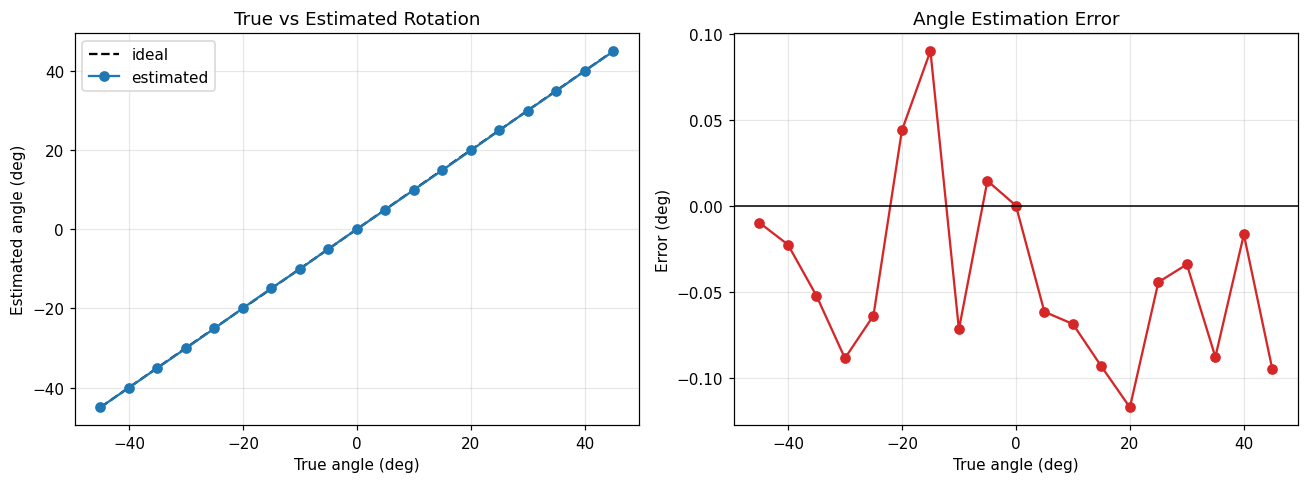

Saved figure: c:\Users\Sinbad\Documents\GitHub\multimedia_security_and_privacy\LSB\tests\fft_rotation_sync_outputs\figures\rotation_estimation_fft_logpolar.png
Saved table: c:\Users\Sinbad\Documents\GitHub\multimedia_security_and_privacy\LSB\tests\fft_rotation_sync_outputs\tables\rotation_estimation_eval.csv


In [8]:
def normalized_cross_corr(a: np.ndarray, b: np.ndarray) -> float:
    a1 = to_gray_u8(a).astype(np.float32)
    b1 = to_gray_u8(b).astype(np.float32)

    a1 = center_crop(a1, frac=0.82)
    b1 = center_crop(b1, frac=0.82)

    a1 = (a1 - a1.mean()) / (a1.std() + 1e-6)
    b1 = (b1 - b1.mean()) / (b1.std() + 1e-6)
    return float((a1 * b1).mean())


def fft_logpolar_map(image: np.ndarray) -> np.ndarray:
    spec = fft2_spectrum(image)
    mag = np.asarray(spec["log_mag_norm"], dtype=np.float32)

    h, w = mag.shape
    center = (w / 2.0, h / 2.0)
    max_radius = min(center)

    lp = cv2.warpPolar(
        mag,
        (w, h),
        center,
        max_radius,
        cv2.WARP_POLAR_LOG + cv2.WARP_FILL_OUTLIERS + cv2.INTER_LINEAR,
    )
    lp = cv2.normalize(lp, None, 0.0, 1.0, cv2.NORM_MINMAX)
    return lp.astype(np.float32)


def estimate_rotation_fft_logpolar(reference: np.ndarray, attacked: np.ndarray) -> Dict[str, float]:
    lp_ref = fft_logpolar_map(reference)
    lp_att = fft_logpolar_map(attacked)

    win = cv2.createHanningWindow((lp_ref.shape[1], lp_ref.shape[0]), cv2.CV_32F)
    shift_xy, response = cv2.phaseCorrelate(lp_ref * win, lp_att * win)
    dx, dy = shift_xy

    angle_from_dy = 360.0 * dy / float(lp_ref.shape[0])
    candidate_angles = [wrap_angle_deg(angle_from_dy), wrap_angle_deg(-angle_from_dy)]

    scored: List[Tuple[float, float]] = []
    for est_angle in candidate_angles:
        corrected = rotate_image(attacked, -est_angle, interpolation=cv2.INTER_CUBIC)
        score = normalized_cross_corr(reference, corrected)
        scored.append((score, est_angle))

    best_score, best_angle = max(scored, key=lambda t: t[0])
    return {
        "angle_deg": float(best_angle),
        "phase_corr_response": float(response),
        "logpolar_shift_dx": float(dx),
        "logpolar_shift_dy": float(dy),
        "alignment_score": float(best_score),
    }


rot_eval_rows: List[Dict[str, float]] = []
for gt_angle in rotation_sweep_angles:
    attacked = rotate_image(ref_clean, float(gt_angle), interpolation=cv2.INTER_CUBIC)
    est = estimate_rotation_fft_logpolar(ref_clean, attacked)

    err = wrap_angle_deg(est["angle_deg"] - float(gt_angle))
    rot_eval_rows.append(
        {
            "true_angle_deg": float(gt_angle),
            "estimated_angle_deg": float(est["angle_deg"]),
            "angle_error_deg": float(err),
            "phase_corr_response": float(est["phase_corr_response"]),
            "alignment_score": float(est["alignment_score"]),
        }
    )

rot_eval_df = pd.DataFrame(rot_eval_rows)
mae = float(np.abs(rot_eval_df["angle_error_deg"]).mean())
rmse = float(np.sqrt(np.mean(rot_eval_df["angle_error_deg"] ** 2)))

print(f"Rotation estimation MAE:  {mae:.3f} deg")
print(f"Rotation estimation RMSE: {rmse:.3f} deg")
display(rot_eval_df.head(10))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(rot_eval_df["true_angle_deg"], rot_eval_df["true_angle_deg"], "k--", label="ideal")
axes[0].plot(rot_eval_df["true_angle_deg"], rot_eval_df["estimated_angle_deg"], "o-", label="estimated")
axes[0].set_title("True vs Estimated Rotation")
axes[0].set_xlabel("True angle (deg)")
axes[0].set_ylabel("Estimated angle (deg)")
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].plot(rot_eval_df["true_angle_deg"], rot_eval_df["angle_error_deg"], "o-", color="tab:red")
axes[1].axhline(0.0, color="black", linewidth=1)
axes[1].set_title("Angle Estimation Error")
axes[1].set_xlabel("True angle (deg)")
axes[1].set_ylabel("Error (deg)")
axes[1].grid(alpha=0.3)

plt.tight_layout()
rot_est_fig = OUT_DIR / "figures" / "rotation_estimation_fft_logpolar.png"
plt.savefig(rot_est_fig, bbox_inches="tight")
plt.show()
print(f"Saved figure: {rot_est_fig}")

rot_eval_csv = OUT_DIR / "tables" / "rotation_estimation_eval.csv"
rot_eval_df.to_csv(rot_eval_csv, index=False)
print(f"Saved table: {rot_eval_csv}")

## 9) Integrate `WatermarkModel` Decode Diagnostics per Attack

We embed a known watermark bit pattern into a reference image, run attacks, and decode using `decode_verbose`.

Collected metrics:
- `transform` chosen by decode search
- `embedding_strength`
- `overall_confidence`
- Bit accuracy and BER

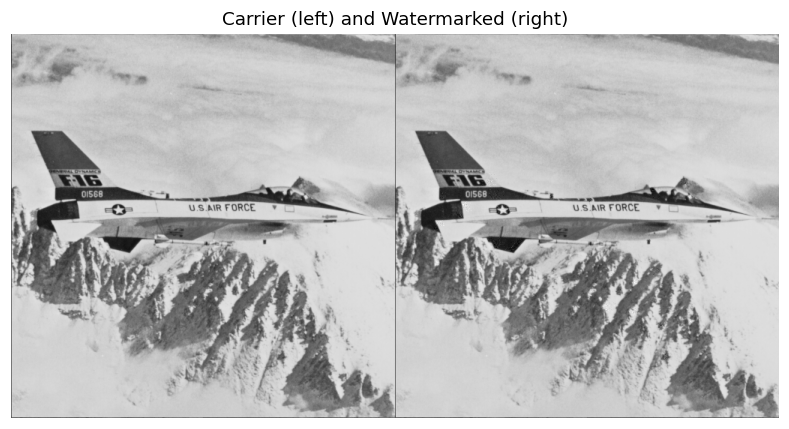

Saved pre-sync decode table: c:\Users\Sinbad\Documents\GitHub\multimedia_security_and_privacy\LSB\tests\fft_rotation_sync_outputs\tables\decode_metrics_before_sync.csv


,attack_id,angle_deg_true,blur_kernel,blur_sigma,jpeg_quality,attacked_path,decode_transform,embedding_strength,overall_confidence,bit_accuracy,ber
0,wm_a-30_k1_s0.0_q100,-30.0,1,0.0,100,c:\Users\Sinbad\Documents\GitHub\multimedia_se...,rot180,17.189888,0.562500,0.43750,0.56250
1,wm_a-30_k1_s0.0_q70,-30.0,1,0.0,70,c:\Users\Sinbad\Documents\GitHub\multimedia_se...,hflip,17.411205,0.569444,0.40625,0.59375
2,wm_a-30_k1_s0.0_q40,-30.0,1,0.0,40,c:\Users\Sinbad\Documents\GitHub\multimedia_se...,vflip,18.416813,0.575521,0.34375,0.65625
3,wm_a-30_k7_s1.6_q100,-30.0,7,1.6,100,c:\Users\Sinbad\Documents\GitHub\multimedia_se...,rot270,6.713180,0.575521,0.56250,0.43750
4,wm_a-30_k7_s1.6_q70,-30.0,7,1.6,70,c:\Users\Sinbad\Documents\GitHub\multimedia_se...,rot180,6.913557,0.559896,0.56250,0.43750
5,wm_a-30_k7_s1.6_q40,-30.0,7,1.6,40,c:\Users\Sinbad\Documents\GitHub\multimedia_se...,identity,7.544054,0.559028,0.31250,0.68750
6,wm_a-15_k1_s0.0_q100,-15.0,1,0.0,100,c:\Users\Sinbad\Documents\GitHub\multimedia_se...,hflip,17.746891,0.574653,0.37500,0.62500
7,wm_a-15_k1_s0.0_q70,-15.0,1,0.0,70,c:\Users\Sinbad\Documents\GitHub\multimedia_se...,rot270,18.141239,0.570312,0.50000,0.50000
8,wm_a-15_k1_s0.0_q40,-15.0,1,0.0,40,c:\Users\Sinbad\Documents\GitHub\multimedia_se...,vflip,17.310617,0.553819,0.50000,0.50000
9,wm_a-15_k7_s1.6_q100,-15.0,7,1.6,100,c:\Users\Sinbad\Documents\GitHub\multimedia_se...,rot90,6.717412,0.578993,0.59375,0.40625


In [9]:
wm_message_length = 32
rng_bits = np.random.default_rng(1234)
watermark_bits = rng_bits.integers(0, 2, size=wm_message_length, dtype=np.uint8)

wm_model = WatermarkModel(
    message_length=wm_message_length,
    key=1234,
    alpha=18.0,
    msg_repeat=35,
    neighborhood_size=5,
    robust_to_transforms=True,
    confidence_threshold=0.90,
    use_features=True,
    num_features=64,
    patch_size=32,
)

carrier = ref_clean.copy()
watermarked = wm_model.encode(carrier, watermark_bits)

wm_preview = np.hstack([carrier, watermarked])
plt.figure(figsize=(10, 4))
plt.imshow(wm_preview, cmap="gray")
plt.title("Carrier (left) and Watermarked (right)")
plt.axis("off")
plt.tight_layout()
plt.show()

wm_attack_out = OUT_DIR / "attacks" / "watermarked_reference"
wm_attack_out.mkdir(parents=True, exist_ok=True)

wm_angles = [-30, -15, 0, 15, 30]
wm_blurs = [(1, 0.0), (7, 1.6)]
wm_jpegs = [100, 70, 40]

decode_rows: List[Dict[str, object]] = []
for angle in wm_angles:
    for blur_k, blur_sigma in wm_blurs:
        for jpeg_q in wm_jpegs:
            attacked = apply_attack_pipeline(
                watermarked,
                angle_deg=float(angle),
                blur_kernel=int(blur_k),
                blur_sigma=float(blur_sigma),
                jpeg_quality=int(jpeg_q),
            )

            attack_id = (
                f"wm_a{int(angle):+03d}_k{int(blur_k)}"
                f"_s{blur_sigma:.1f}_q{int(jpeg_q)}"
            )
            attacked_path = wm_attack_out / f"{attack_id}.png"
            cv2.imwrite(str(attacked_path), attacked)

            dec = wm_model.decode_verbose(attacked)
            bit_acc = float((dec.bits == watermark_bits).mean())
            ber = float(1.0 - bit_acc)

            decode_rows.append(
                {
                    "attack_id": attack_id,
                    "angle_deg_true": float(angle),
                    "blur_kernel": int(blur_k),
                    "blur_sigma": float(blur_sigma),
                    "jpeg_quality": int(jpeg_q),
                    "attacked_path": str(attacked_path),
                    "decode_transform": dec.transform,
                    "embedding_strength": float(dec.embedding_strength),
                    "overall_confidence": float(dec.overall_confidence),
                    "bit_accuracy": bit_acc,
                    "ber": ber,
                }
            )

decode_df = pd.DataFrame(decode_rows)
decode_csv = OUT_DIR / "tables" / "decode_metrics_before_sync.csv"
decode_df.to_csv(decode_csv, index=False)

print(f"Saved pre-sync decode table: {decode_csv}")
display(decode_df.head(12))

## 10) Apply FFT-Based Rotation Synchronization Before Decoding

For each attacked watermarked image:
1. Estimate rotation angle with FFT log-polar phase correlation.
2. Pre-rotate image by the inverse estimated angle.
3. Decode again and compare against pre-sync metrics.

We track confidence gain $\Delta c$ and BER reduction.

Saved pre/post sync decode table: c:\Users\Sinbad\Documents\GitHub\multimedia_security_and_privacy\LSB\tests\fft_rotation_sync_outputs\tables\decode_metrics_pre_post_sync.csv


,attack_id,angle_deg_true,blur_kernel,blur_sigma,jpeg_quality,estimated_angle_deg,angle_error_deg,phase_corr_response,pre_transform,pre_embedding_strength,pre_confidence,pre_bit_accuracy,pre_ber,post_transform,post_embedding_strength,post_confidence,post_bit_accuracy,post_ber,delta_confidence,ber_reduction
0,wm_a-30_k1_s0.0_q100,-30.0,1,0.0,100,-30.101773,-0.101773,0.379882,rot180,17.189888,0.562500,0.43750,0.56250,vflip,19.043438,0.586806,0.46875,0.53125,0.024306,0.03125
1,wm_a-30_k1_s0.0_q70,-30.0,1,0.0,70,-30.113934,-0.113934,0.373247,hflip,17.411205,0.569444,0.40625,0.59375,identity,19.271992,0.571181,0.65625,0.34375,0.001736,0.25000
2,wm_a-30_k1_s0.0_q40,-30.0,1,0.0,40,-30.103577,-0.103577,0.376297,vflip,18.416813,0.575521,0.34375,0.65625,rot270,18.761356,0.577257,0.59375,0.40625,0.001736,0.25000
3,wm_a-30_k7_s1.6_q100,-30.0,7,1.6,100,-30.072484,-0.072484,0.370393,rot270,6.713180,0.575521,0.56250,0.43750,identity,6.877676,0.577257,0.46875,0.53125,0.001736,-0.09375
4,wm_a-30_k7_s1.6_q70,-30.0,7,1.6,70,-30.085937,-0.085937,0.374313,rot180,6.913557,0.559896,0.56250,0.43750,rot270,6.771050,0.578125,0.56250,0.43750,0.018229,0.00000
5,wm_a-30_k7_s1.6_q40,-30.0,7,1.6,40,-30.039464,-0.039464,0.367646,identity,7.544054,0.559028,0.31250,0.68750,rot180,7.372143,0.578125,0.68750,0.31250,0.019097,0.37500
6,wm_a-15_k1_s0.0_q100,-15.0,1,0.0,100,-14.913747,0.086253,0.468082,hflip,17.746891,0.574653,0.37500,0.62500,rot180,19.429726,0.594618,0.59375,0.40625,0.019965,0.21875
7,wm_a-15_k1_s0.0_q70,-15.0,1,0.0,70,-14.897624,0.102376,0.472961,rot270,18.141239,0.570312,0.50000,0.50000,rot270,19.327545,0.577257,0.50000,0.50000,0.006944,0.00000
8,wm_a-15_k1_s0.0_q40,-15.0,1,0.0,40,-14.906232,0.093768,0.467096,vflip,17.310617,0.553819,0.50000,0.50000,rot90,19.164461,0.593750,0.43750,0.56250,0.039931,-0.06250
9,wm_a-15_k7_s1.6_q100,-15.0,7,1.6,100,-14.932175,0.067825,0.482139,rot90,6.717412,0.578993,0.59375,0.40625,rot270,6.889757,0.559896,0.43750,0.56250,-0.019097,-0.15625


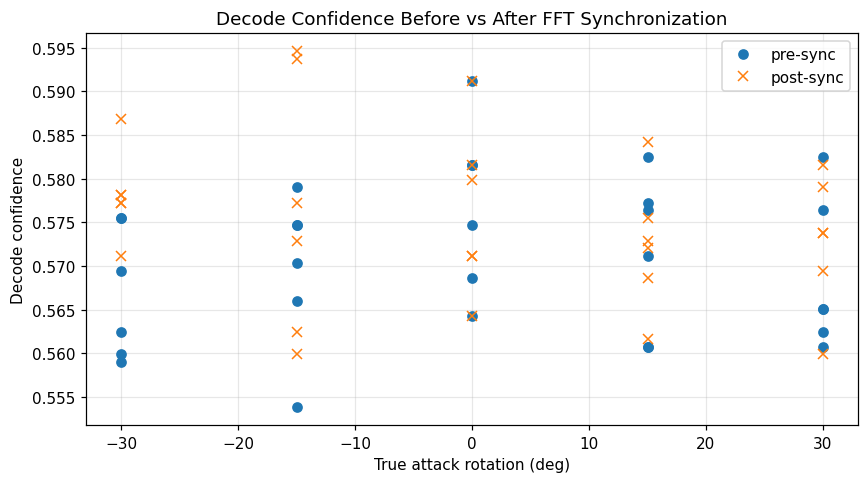

Saved figure: c:\Users\Sinbad\Documents\GitHub\multimedia_security_and_privacy\LSB\tests\fft_rotation_sync_outputs\figures\confidence_pre_post_sync.png


In [10]:
sync_rows: List[Dict[str, object]] = []
for row in decode_df.to_dict("records"):
    attacked = cv2.imread(str(row["attacked_path"]), cv2.IMREAD_GRAYSCALE)
    if attacked is None:
        print(f"[WARN] Missing attacked image: {row['attacked_path']}")
        continue

    est = estimate_rotation_fft_logpolar(watermarked, attacked)
    synced = rotate_image(attacked, -float(est["angle_deg"]), interpolation=cv2.INTER_CUBIC)

    dec_after = wm_model.decode_verbose(synced)
    post_acc = float((dec_after.bits == watermark_bits).mean())
    post_ber = float(1.0 - post_acc)

    pre_conf = float(row["overall_confidence"])
    pre_acc = float(row["bit_accuracy"])
    pre_ber = float(row["ber"])

    sync_rows.append(
        {
            "attack_id": row["attack_id"],
            "angle_deg_true": float(row["angle_deg_true"]),
            "blur_kernel": int(row["blur_kernel"]),
            "blur_sigma": float(row["blur_sigma"]),
            "jpeg_quality": int(row["jpeg_quality"]),
            "estimated_angle_deg": float(est["angle_deg"]),
            "angle_error_deg": float(wrap_angle_deg(float(est["angle_deg"]) - float(row["angle_deg_true"]))),
            "phase_corr_response": float(est["phase_corr_response"]),
            "pre_transform": str(row["decode_transform"]),
            "pre_embedding_strength": float(row["embedding_strength"]),
            "pre_confidence": pre_conf,
            "pre_bit_accuracy": pre_acc,
            "pre_ber": pre_ber,
            "post_transform": dec_after.transform,
            "post_embedding_strength": float(dec_after.embedding_strength),
            "post_confidence": float(dec_after.overall_confidence),
            "post_bit_accuracy": post_acc,
            "post_ber": post_ber,
            "delta_confidence": float(dec_after.overall_confidence - pre_conf),
            "ber_reduction": float(pre_ber - post_ber),
        }
    )

sync_df = pd.DataFrame(sync_rows)
sync_csv = OUT_DIR / "tables" / "decode_metrics_pre_post_sync.csv"
sync_df.to_csv(sync_csv, index=False)

print(f"Saved pre/post sync decode table: {sync_csv}")
display(sync_df.head(12))

plt.figure(figsize=(8, 4.5))
plt.plot(sync_df["angle_deg_true"], sync_df["pre_confidence"], "o", label="pre-sync")
plt.plot(sync_df["angle_deg_true"], sync_df["post_confidence"], "x", label="post-sync")
plt.xlabel("True attack rotation (deg)")
plt.ylabel("Decode confidence")
plt.title("Decode Confidence Before vs After FFT Synchronization")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
conf_fig = OUT_DIR / "figures" / "confidence_pre_post_sync.png"
plt.savefig(conf_fig, bbox_inches="tight")
plt.show()
print(f"Saved figure: {conf_fig}")

## 11) Summarize Results in Tables/Plots (Angle Error, Confidence, Bit Accuracy)

We aggregate by attack parameters and produce:
- Grouped statistic tables
- Heatmaps for confidence gain and BER reduction
- Trend plots for angle estimation error

Overall summary:


,count,mean,std,min,25%,50%,75%,max
angle_error_deg,30.0,-0.024579,0.067276,-0.118963,-0.083228,-0.020675,-0.001047,0.102376
pre_confidence,30.0,0.570775,0.008913,0.553819,0.562934,0.570747,0.576389,0.591146
post_confidence,30.0,0.575376,0.009139,0.559896,0.571181,0.574653,0.579644,0.594618
delta_confidence,30.0,0.004601,0.013691,-0.022569,-0.001736,0.001736,0.011936,0.039931
pre_bit_accuracy,30.0,0.488542,0.087809,0.312500,0.437500,0.500000,0.554688,0.656250
post_bit_accuracy,30.0,0.493750,0.108066,0.250000,0.437500,0.468750,0.562500,0.718750
ber_reduction,30.0,0.005208,0.154643,-0.250000,-0.085938,0.000000,0.000000,0.375000


Saved grouped summary: c:\Users\Sinbad\Documents\GitHub\multimedia_security_and_privacy\LSB\tests\fft_rotation_sync_outputs\tables\summary_by_attack.csv


,angle_deg_true,blur_kernel,jpeg_quality,angle_error_deg,pre_confidence,post_confidence,delta_confidence,pre_bit_accuracy,post_bit_accuracy,ber_reduction
0,-30.0,1,40,-0.103577,0.575521,0.577257,0.001736,0.34375,0.59375,0.25000
1,-30.0,1,70,-0.113934,0.569444,0.571181,0.001736,0.40625,0.65625,0.25000
2,-30.0,1,100,-0.101773,0.562500,0.586806,0.024306,0.43750,0.46875,0.03125
3,-30.0,7,40,-0.039464,0.559028,0.578125,0.019097,0.31250,0.68750,0.37500
4,-30.0,7,70,-0.085937,0.559896,0.578125,0.018229,0.56250,0.56250,0.00000
5,-30.0,7,100,-0.072484,0.575521,0.577257,0.001736,0.56250,0.46875,-0.09375
6,-15.0,1,40,0.093768,0.553819,0.593750,0.039931,0.50000,0.43750,-0.06250
7,-15.0,1,70,0.102376,0.570312,0.577257,0.006944,0.50000,0.50000,0.00000
8,-15.0,1,100,0.086253,0.574653,0.594618,0.019965,0.37500,0.59375,0.21875
9,-15.0,7,40,0.055033,0.565972,0.562500,-0.003472,0.62500,0.37500,-0.25000


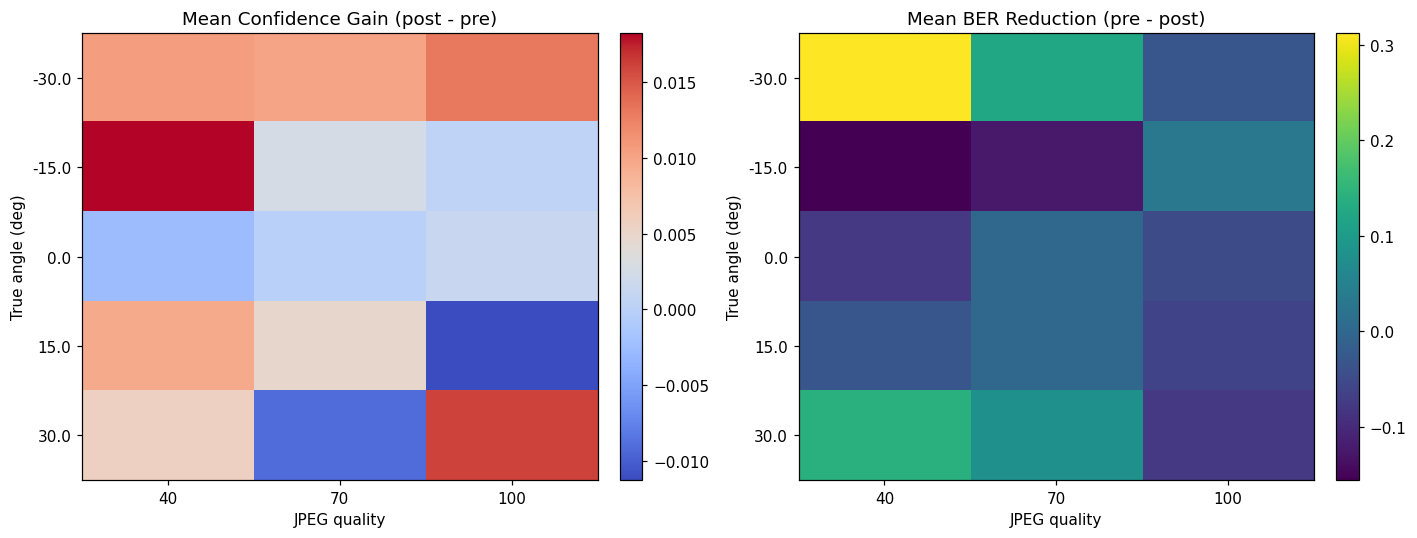

Saved figure: c:\Users\Sinbad\Documents\GitHub\multimedia_security_and_privacy\LSB\tests\fft_rotation_sync_outputs\figures\summary_heatmaps.png


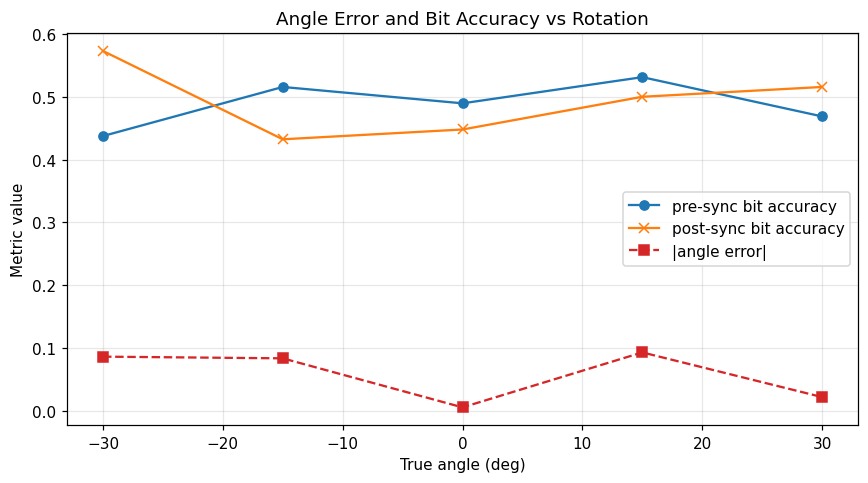

Saved figure: c:\Users\Sinbad\Documents\GitHub\multimedia_security_and_privacy\LSB\tests\fft_rotation_sync_outputs\figures\angle_error_and_accuracy_trends.png
Notebook pipeline completed.


In [11]:
summary_cols = [
    "angle_error_deg",
    "pre_confidence",
    "post_confidence",
    "delta_confidence",
    "pre_bit_accuracy",
    "post_bit_accuracy",
    "ber_reduction",
]

overall_summary = sync_df[summary_cols].describe().T
print("Overall summary:")
display(overall_summary)

by_attack = (
    sync_df.groupby(["angle_deg_true", "blur_kernel", "jpeg_quality"], as_index=False)[summary_cols]
    .mean()
    .sort_values(["angle_deg_true", "blur_kernel", "jpeg_quality"])
)

by_attack_csv = OUT_DIR / "tables" / "summary_by_attack.csv"
by_attack.to_csv(by_attack_csv, index=False)
print(f"Saved grouped summary: {by_attack_csv}")
display(by_attack.head(12))

heat_conf = sync_df.pivot_table(
    index="angle_deg_true",
    columns="jpeg_quality",
    values="delta_confidence",
    aggfunc="mean",
)
heat_ber = sync_df.pivot_table(
    index="angle_deg_true",
    columns="jpeg_quality",
    values="ber_reduction",
    aggfunc="mean",
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

im0 = axes[0].imshow(heat_conf.values, aspect="auto", cmap="coolwarm")
axes[0].set_title("Mean Confidence Gain (post - pre)")
axes[0].set_xlabel("JPEG quality")
axes[0].set_ylabel("True angle (deg)")
axes[0].set_xticks(np.arange(len(heat_conf.columns)))
axes[0].set_xticklabels([str(c) for c in heat_conf.columns])
axes[0].set_yticks(np.arange(len(heat_conf.index)))
axes[0].set_yticklabels([str(i) for i in heat_conf.index])
fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

im1 = axes[1].imshow(heat_ber.values, aspect="auto", cmap="viridis")
axes[1].set_title("Mean BER Reduction (pre - post)")
axes[1].set_xlabel("JPEG quality")
axes[1].set_ylabel("True angle (deg)")
axes[1].set_xticks(np.arange(len(heat_ber.columns)))
axes[1].set_xticklabels([str(c) for c in heat_ber.columns])
axes[1].set_yticks(np.arange(len(heat_ber.index)))
axes[1].set_yticklabels([str(i) for i in heat_ber.index])
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

plt.tight_layout()
heatmap_path = OUT_DIR / "figures" / "summary_heatmaps.png"
plt.savefig(heatmap_path, bbox_inches="tight")
plt.show()
print(f"Saved figure: {heatmap_path}")

plt.figure(figsize=(8, 4.5))
angle_group = sync_df.groupby("angle_deg_true", as_index=False)[["angle_error_deg", "pre_bit_accuracy", "post_bit_accuracy"]].mean()

plt.plot(angle_group["angle_deg_true"], angle_group["pre_bit_accuracy"], "o-", label="pre-sync bit accuracy")
plt.plot(angle_group["angle_deg_true"], angle_group["post_bit_accuracy"], "x-", label="post-sync bit accuracy")
plt.plot(angle_group["angle_deg_true"], np.abs(angle_group["angle_error_deg"]), "s--", label="|angle error|", color="tab:red")
plt.xlabel("True angle (deg)")
plt.ylabel("Metric value")
plt.title("Angle Error and Bit Accuracy vs Rotation")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
trend_path = OUT_DIR / "figures" / "angle_error_and_accuracy_trends.png"
plt.savefig(trend_path, bbox_inches="tight")
plt.show()
print(f"Saved figure: {trend_path}")

print("Notebook pipeline completed.")